<a href="https://colab.research.google.com/github/xiomara-udea/garbage-classification-dataset/blob/main/02_preprocesado.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## **PREPROCESADO - GARBAGE CLASSIFICATION**

### **Descarga y carga del dataset**

In [ ]:
!kaggle datasets download -d namanjain001/garbage-classification-dataset
!unzip -q garbage-classification-dataset.zip

Dataset URL: https://www.kaggle.com/datasets/namanjain001/garbage-classification-dataset
License(s): Attribution 4.0 International (CC BY 4.0)
100% 87.3M/87.3M [00:00<00:00, 124MB/s]



### **Librerías**

In [ ]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split

import tensorflow as tf

from tensorflow.keras.preprocessing.image import ImageDataGenerator

### **Ruta del Dataset**

In [ ]:
dataset_path = "Final Dataset"
print(os.listdir(dataset_path))

['trash', 'cardboard', 'brown-glass', 'plastic', 'battery', 'biological', 'metal', 'white-glass', 'paper', 'green-glass']


### **Construcción del Dataframe**

In [ ]:
imagenes = []
etiquetas = []

for clase in os.listdir(dataset_path):
    ruta_clase = os.path.join(dataset_path, clase)
    if os.path.isdir(ruta_clase):

        for archivo in os.listdir(ruta_clase):
            imagenes.append(
                os.path.join(ruta_clase, archivo)
            )

            etiquetas.append(clase)

In [ ]:
df = pd.DataFrame({
    "ruta": imagenes,
    "clase": etiquetas
})

df.head()

,ruta,clase
0,Final Dataset/trash/trash433.jpg,trash
1,Final Dataset/trash/trash660.jpg,trash
2,Final Dataset/trash/trash5.jpg,trash
3,Final Dataset/trash/trash486.jpg,trash
4,Final Dataset/trash/trash170.jpg,trash


### **Verificación del Dataset**

In [ ]:
print("Número total de imágenes:", len(df))

Número total de imágenes: 8775


In [ ]:
df["clase"].value_counts()

,count
clase,
cardboard,1000
plastic,1000
paper,1000
battery,1000
biological,1000
metal,1000
white-glass,777
trash,666
brown-glass,666


### **División Train/Validation/Test**

70% de entrenamiento
15% de validación
15% de prueba


**Train vs Temp**

In [ ]:
train_df, temp_df = train_test_split(
    df,
    test_size=0.30,
    stratify=df["clase"],
    random_state=42
)

**Validación vs Test**

In [ ]:
val_df, test_df = train_test_split(
    temp_df,
    test_size=0.50,
    stratify=temp_df["clase"],
    random_state=42
)

In [ ]:
print("Train:", len(train_df))
print("Validation:", len(val_df))
print("Test:", len(test_df))

Train: 6142
Validation: 1316
Test: 1317


### **Comprobar distribución**

In [ ]:
print("TRAIN")
print(train_df["clase"].value_counts())

print("\nVALIDATION")
print(val_df["clase"].value_counts())

print("\nTEST")
print(test_df["clase"].value_counts())

#Esto demuestra que se mantuvo el balance en las clases

TRAIN
clase
biological     700
plastic        700
paper          700
cardboard      700
battery        700
metal          700
white-glass    544
trash          466
brown-glass    466
green-glass    466
Name: count, dtype: int64

VALIDATION
clase
metal          150
plastic        150
biological     150
cardboard      150
paper          150
battery        150
white-glass    116
brown-glass    100
trash          100
green-glass    100
Name: count, dtype: int64

TEST
clase
paper          150
cardboard      150
plastic        150
battery        150
metal          150
biological     150
white-glass    117
trash          100
green-glass    100
brown-glass    100
Name: count, dtype: int64


### **Parámetros de imagen**

In [ ]:
#VGG16 utiliza
IMG_SIZE = (224,224)

BATCH_SIZE = 32

### **Generador de entrenamiento**

In [ ]:
# Aquí realizamos normalización y Data Augmentation

train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    zoom_range=0.2,
    width_shift_range=0.1,
    height_shift_range=0.1,
    horizontal_flip=True
)

### **Validación**

In [ ]:
val_datagen = ImageDataGenerator(
    rescale=1./255
)

### **Test**

In [ ]:
test_datagen = ImageDataGenerator(
    rescale=1./255
)

### **Crear generadores**

**Train**

In [ ]:
train_generator = train_datagen.flow_from_dataframe(
    train_df,

    x_col="ruta",
    y_col="clase",

    target_size=IMG_SIZE,

    batch_size=BATCH_SIZE,

    class_mode="categorical",

    shuffle=True
)

Found 6142 validated image filenames belonging to 10 classes.


**Validation**

In [ ]:
val_generator = val_datagen.flow_from_dataframe(
    val_df,

    x_col="ruta",
    y_col="clase",

    target_size=IMG_SIZE,

    batch_size=BATCH_SIZE,

    class_mode="categorical",

    shuffle=False
)

Found 1316 validated image filenames belonging to 10 classes.


**Test**

In [ ]:
test_generator = test_datagen.flow_from_dataframe(
    test_df,

    x_col="ruta",
    y_col="clase",

    target_size=IMG_SIZE,

    batch_size=BATCH_SIZE,

    class_mode="categorical",

    shuffle=False
)

Found 1317 validated image filenames belonging to 10 classes.


### **Verificar clases**

In [ ]:
train_generator.class_indices

{'battery': 0,
 'biological': 1,
 'brown-glass': 2,
 'cardboard': 3,
 'green-glass': 4,
 'metal': 5,
 'paper': 6,
 'plastic': 7,
 'trash': 8,
 'white-glass': 9}

### **Visualizar imágenes preprocesadas**

In [ ]:
imagenes, etiquetas = next(train_generator)

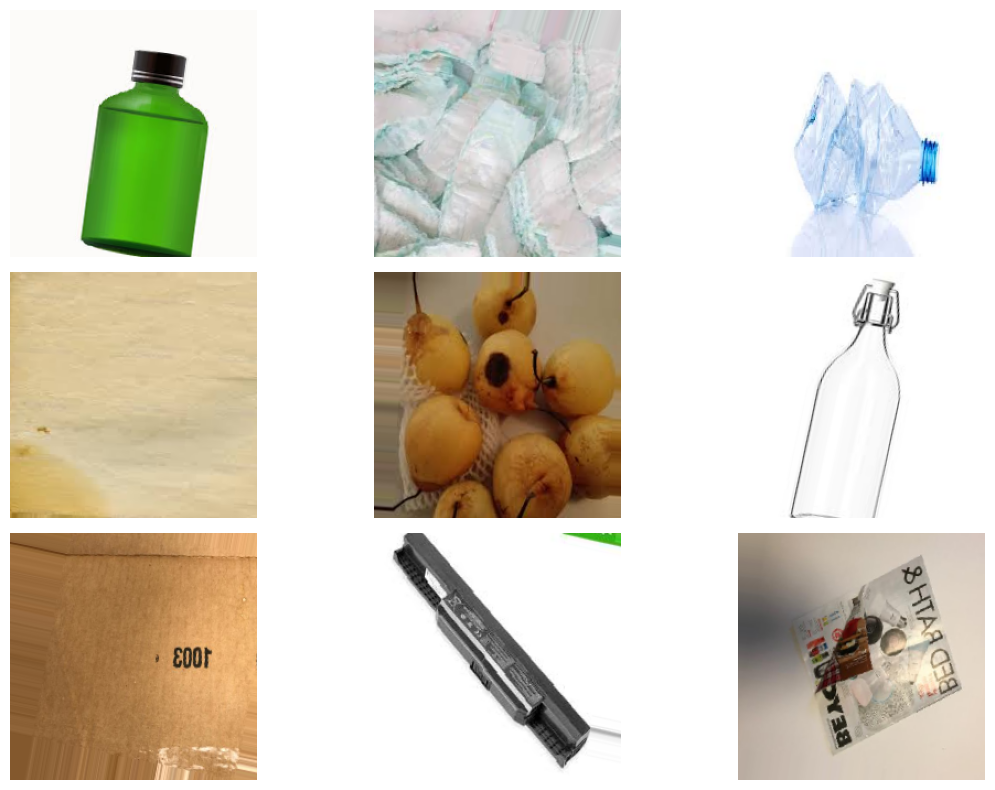

In [ ]:
plt.figure(figsize=(12,8))

for i in range(9):

    plt.subplot(3,3,i+1)

    plt.imshow(imagenes[i])

    plt.axis("off")

plt.tight_layout()
plt.show()

### **Verificar rango de normalización**

In [ ]:
print("Mínimo:", imagenes.min())
print("Máximo:", imagenes.max())

Mínimo: 0.0
Máximo: 1.0


### **Guardar información para notebooks posteriores**

In [ ]:
train_df.to_csv("train_split.csv", index=False)
val_df.to_csv("val_split.csv", index=False)
test_df.to_csv("test_split.csv", index=False)

print("Archivos guardados correctamente")

Archivos guardados correctamente


In [ ]:
import os

print(os.listdir())

['.config', 'garbage-classification-dataset.zip', 'train_split.csv', 'test_split.csv', 'val_split.csv', 'Final Dataset', 'sample_data']


# Conclusiones

- Se consolidó el dataset en un DataFrame con rutas y etiquetas.
- Se realizó una división estratificada:
  - 70% entrenamiento
  - 15% validación
  - 15% prueba
- Las imágenes fueron redimensionadas a 224x224 píxeles.
- Se normalizaron los valores de píxel al rango [0,1].
- Se aplicó Data Augmentation para mejorar la capacidad de generalización de los modelos.
- Los generadores quedaron preparados para ser utilizados en los notebooks de entrenamiento de CNN y Transfer Learning.